In [4]:
# import the required packages
import pandas as pd
import numpy as np


In [5]:
# Load the SQL toolset extension
%load_ext sql

The sql extension is already loaded. To reload it, use:
  %reload_ext sql


In [7]:
#2. Connect to (and create) the database file
%sql sqlite:///bike_orders_database.sqlite

In [15]:
def collect_data():
    """
    Collects and combines the bike orders data using the jupyter-sql magic extension.
    """
    
    # 1.0 Connect to database and load tables via SQL magic
    # Using the %sql magic command to fetch data directly into DataFrames
    bikes     = %sql SELECT * FROM bikes;
    bikeshops = %sql SELECT * FROM bikeshops;
    orderlines = %sql SELECT * FROM orderlines;
    
    # Convert to DataFrames and drop 'index' column
    data_dict = {
        'bikes': bikes.DataFrame().drop("index", axis=1),
        'bikeshops': bikeshops.DataFrame().drop("index", axis=1),
        'orderlines': orderlines.DataFrame().drop("index", axis=1)
    }

    # 2.0 Combining Data
    joined_df = data_dict['orderlines'] \
        .merge(
            right    = data_dict['bikes'],
            how      = 'left',
            left_on  = 'product.id',
            right_on = 'bike.id'
        ) \
        .merge(
            right    = data_dict['bikeshops'],
            how      = "left",
            left_on  = "customer.id",
            right_on = 'bikeshop.id'
        )

    # 3.0 Cleaning Data 
    df = joined_df
    df['order.date'] = pd.to_datetime(df['order.date'])

    temp_df = df['description'].str.split(" - ", expand = True)
    df['category.1'] = temp_df[0]
    df['category.2'] = temp_df[1]
    df['frame.material'] = temp_df[2]

    temp_df = df['location'].str.split(", ", expand = True)
    df['city'] = temp_df[0]
    df['state'] = temp_df[1]

    df['total.price'] = df['quantity'] * df['price']

    cols_to_keep_list = [
        'order.id', 'order.line', 'order.date',    
        'quantity', 'price', 'total.price', 
        'model', 'category.1', 'category.2', 'frame.material', 
        'bikeshop.name', 'city', 'state'
    ]

    df = df[cols_to_keep_list]
    df.columns = df.columns.str.replace(".", "_")

    return df

In [18]:
df = collect_data()

 * sqlite:///bike_orders_database.sqlite
Done.
 * sqlite:///bike_orders_database.sqlite
Done.
 * sqlite:///bike_orders_database.sqlite
Done.


In [17]:
%config SqlMagic.style = '_DEPRECATED_DEFAULT'

# 1. Selecting Columns

### Select by name
![Select by name](subset_cols.png)

In [20]:
df

,order_id,order_line,order_date,quantity,price,total_price,model,category_1,category_2,frame_material,bikeshop_name,city,state
0,1,1,2011-01-07,1,6070,6070,Jekyll Carbon 2,Mountain,Over Mountain,Carbon,Ithaca Mountain Climbers,Ithaca,NY
1,1,2,2011-01-07,1,5970,5970,Trigger Carbon 2,Mountain,Over Mountain,Carbon,Ithaca Mountain Climbers,Ithaca,NY
2,2,1,2011-01-10,1,2770,2770,Beast of the East 1,Mountain,Trail,Aluminum,Kansas City 29ers,Kansas City,KS
3,2,2,2011-01-10,1,5970,5970,Trigger Carbon 2,Mountain,Over Mountain,Carbon,Kansas City 29ers,Kansas City,KS
4,3,1,2011-01-10,1,10660,10660,Supersix Evo Hi-Mod Team,Road,Elite Road,Carbon,Louisville Race Equipment,Louisville,KY
...,...,...,...,...,...,...,...,...,...,...,...,...,...
15639,2000,4,2015-12-25,1,2660,2660,CAAD Disc Ultegra,Road,Elite Road,Aluminum,Austin Cruisers,Austin,TX
15640,2000,5,2015-12-25,1,1350,1350,Trail 2,Mountain,Sport,Aluminum,Austin Cruisers,Austin,TX
15641,2000,6,2015-12-25,1,1680,1680,CAAD12 105,Road,Elite Road,Aluminum,Austin Cruisers,Austin,TX
15642,2000,7,2015-12-25,1,2880,2880,F-Si Carbon 4,Mountain,Cross Country Race,Carbon,Austin Cruisers,Austin,TX


In [22]:
[1,2,3, "hello",[7,8,9]]
df['order_date']

0       2011-01-07
1       2011-01-07
2       2011-01-10
3       2011-01-10
4       2011-01-10
           ...    
15639   2015-12-25
15640   2015-12-25
15641   2015-12-25
15642   2015-12-25
15643   2015-12-25
Name: order_date, Length: 15644, dtype: datetime64[us]

In [19]:
# Select by name
# Subsetting data frame columns with a list of names
['order_date', 'order_id', 'order_line'] # make a list
df[['order_date', 'order_id', 'order_line']] # get the specific cols in the order we pass them
# df['order_date', 'order_id'] # we will get an error. Pandas is trying to index those columns
df['order_date'] # we will get a series with a single bracket
type(df['order_date'])
df[['order_date']] # we will get a data frame with double brackets
type(df[['order_date']])

pandas.DataFrame

### Select by position
In pandas, *loc* and *iloc* are the primary tools for selecting data from a DataFrame. The fundamental difference lies in how they identify the data: *loc* is label-based, while *iloc* is integer-position-based.
```python
df.loc[row_label, column_label]
df.iloc[row_position, column_position]
```
![Select by position](subset_iloc.png)

In [23]:
df

,order_id,order_line,order_date,quantity,price,total_price,model,category_1,category_2,frame_material,bikeshop_name,city,state
0,1,1,2011-01-07,1,6070,6070,Jekyll Carbon 2,Mountain,Over Mountain,Carbon,Ithaca Mountain Climbers,Ithaca,NY
1,1,2,2011-01-07,1,5970,5970,Trigger Carbon 2,Mountain,Over Mountain,Carbon,Ithaca Mountain Climbers,Ithaca,NY
2,2,1,2011-01-10,1,2770,2770,Beast of the East 1,Mountain,Trail,Aluminum,Kansas City 29ers,Kansas City,KS
3,2,2,2011-01-10,1,5970,5970,Trigger Carbon 2,Mountain,Over Mountain,Carbon,Kansas City 29ers,Kansas City,KS
4,3,1,2011-01-10,1,10660,10660,Supersix Evo Hi-Mod Team,Road,Elite Road,Carbon,Louisville Race Equipment,Louisville,KY
...,...,...,...,...,...,...,...,...,...,...,...,...,...
15639,2000,4,2015-12-25,1,2660,2660,CAAD Disc Ultegra,Road,Elite Road,Aluminum,Austin Cruisers,Austin,TX
15640,2000,5,2015-12-25,1,1350,1350,Trail 2,Mountain,Sport,Aluminum,Austin Cruisers,Austin,TX
15641,2000,6,2015-12-25,1,1680,1680,CAAD12 105,Road,Elite Road,Aluminum,Austin Cruisers,Austin,TX
15642,2000,7,2015-12-25,1,2880,2880,F-Si Carbon 4,Mountain,Cross Country Race,Carbon,Austin Cruisers,Austin,TX


In [26]:
# Select by position
# iloc
df.iloc[:, 0:3] # select all rows and cols 0 to 3
df.iloc[:, -3:] # Last 3

# loc
# Select all rows where price is greater than 12000
df.loc[df['price'] > 12000]


,order_id,order_line,order_date,quantity,price,total_price,model,category_1,category_2,frame_material,bikeshop_name,city,state
6,3,3,2011-01-10,1,12790,12790,Supersix Evo Black Inc.,Road,Elite Road,Carbon,Louisville Race Equipment,Louisville,KY
23,7,6,2011-01-12,1,12790,12790,Scalpel-Si Black Inc.,Mountain,Cross Country Race,Carbon,Minneapolis Bike Shop,Minneapolis,MN
79,15,9,2011-01-25,1,12790,12790,Supersix Evo Black Inc.,Road,Elite Road,Carbon,Oklahoma City Race Equipment,Oklahoma City,OK
218,34,12,2011-02-16,1,12790,12790,Scalpel-Si Black Inc.,Mountain,Cross Country Race,Carbon,Kansas City 29ers,Kansas City,KS
240,35,9,2011-02-17,1,12790,12790,Supersix Evo Black Inc.,Road,Elite Road,Carbon,Portland Bi-peds,Portland,OR
...,...,...,...,...,...,...,...,...,...,...,...,...,...
15489,1979,2,2015-12-09,1,12790,12790,Scalpel-Si Black Inc.,Mountain,Cross Country Race,Carbon,Denver Bike Shop,Denver,CO
15505,1980,3,2015-12-09,1,12790,12790,Supersix Evo Black Inc.,Road,Elite Road,Carbon,Ithaca Mountain Climbers,Ithaca,NY
15525,1982,6,2015-12-10,1,12790,12790,Scalpel-Si Black Inc.,Mountain,Cross Country Race,Carbon,Tampa 29ers,Tampa,FL
15587,1992,3,2015-12-22,2,12790,25580,Scalpel-Si Black Inc.,Mountain,Cross Country Race,Carbon,Los Angeles Cycles,Los Angeles,CA


In [27]:
# Select by text matching
# Use df.filter().  Filter is based on column or row index using text patterns
# The pandas filter() function is a specialized tool used to subset a DataFrame or Series based on labels 
# rather than values. It is highly useful when you need to select columns or index rows that match 
# specific naming patterns, such as prefixes or suffixes.
# If they try to use it to filter rows based on the content of a column (like filter(quantity > 5)), 
# it will throw an error. For content-based filtering, they should use boolean indexing instead 
# (e.g., df[df['quantity'] > 5]).
# Most of the time I use:
#  "term" = Contains "term"
#  "^term" = Starts with "term"
#  "term$" = Ends with "term"
#  (term1)|(term2) = Matches "term1" or "term2"

df.filter(regex="(^model)|(^cat)", axis=1)  # everything that starts with model or starts with cat
df.filter(regex="(id$)", axis=1)
df.filter(regex="(price)", axis=1)


,price,total_price
0,6070,6070
1,5970,5970
2,2770,2770
3,5970,5970
4,10660,10660
...,...,...
15639,2660,2660
15640,1350,1350
15641,1680,1680
15642,2880,2880


In [33]:
?pd.DataFrame.filter

Signature:
pd.DataFrame.filter(
    self,
    items=None,
    like: 'str | None' = None,
    regex: 'str | None' = None,
    axis: 'Axis | None' = None,
) -> 'Self'
Docstring:
Subset the DataFrame or Series according to the specified index labels.

For DataFrame, filter rows or columns depending on ``axis`` argument.
Note that this routine does not filter based on content.
The filter is applied to the labels of the index.

Parameters
----------
items : list-like
    Keep labels from axis which are in items.
like : str
    Keep labels from axis for which "like in label == True".
regex : str (regular expression)
    Keep labels from axis for which re.search(regex, label) == True.
axis : {0 or 'index', 1 or 'columns', None}, default None
    The axis to filter on, expressed either as an index (int)
    or axis name (str). By default this is the info axis, 'columns' for
    ``DataFrame``. For ``Series`` this parameter is unused and defaults to
    ``None``.

Returns
-------
Same type as ca

In [28]:
# Rearranging a single column
# Move 'model' to the front
df.columns
df.columns.tolist()  # converts a column or row index to a list, which is iterable
l = df.columns.tolist()
l.remove('model')
l  # l does not have the model column now
# df[['model', l]] # I want the column model first.  This is going to throw an error
['model', l] # I get a nested list
['model', *l] # I unpack the list
df[['model', *l]] # unpack the list

,model,order_id,order_line,order_date,quantity,price,total_price,category_1,category_2,frame_material,bikeshop_name,city,state
0,Jekyll Carbon 2,1,1,2011-01-07,1,6070,6070,Mountain,Over Mountain,Carbon,Ithaca Mountain Climbers,Ithaca,NY
1,Trigger Carbon 2,1,2,2011-01-07,1,5970,5970,Mountain,Over Mountain,Carbon,Ithaca Mountain Climbers,Ithaca,NY
2,Beast of the East 1,2,1,2011-01-10,1,2770,2770,Mountain,Trail,Aluminum,Kansas City 29ers,Kansas City,KS
3,Trigger Carbon 2,2,2,2011-01-10,1,5970,5970,Mountain,Over Mountain,Carbon,Kansas City 29ers,Kansas City,KS
4,Supersix Evo Hi-Mod Team,3,1,2011-01-10,1,10660,10660,Road,Elite Road,Carbon,Louisville Race Equipment,Louisville,KY
...,...,...,...,...,...,...,...,...,...,...,...,...,...
15639,CAAD Disc Ultegra,2000,4,2015-12-25,1,2660,2660,Road,Elite Road,Aluminum,Austin Cruisers,Austin,TX
15640,Trail 2,2000,5,2015-12-25,1,1350,1350,Mountain,Sport,Aluminum,Austin Cruisers,Austin,TX
15641,CAAD12 105,2000,6,2015-12-25,1,1680,1680,Road,Elite Road,Aluminum,Austin Cruisers,Austin,TX
15642,F-Si Carbon 4,2000,7,2015-12-25,1,2880,2880,Mountain,Cross Country Race,Carbon,Austin Cruisers,Austin,TX


In [29]:
# Rearranging multiple columns
# Move 'model', 'category_1', and 'category_2' to the front
l = df.columns.tolist()
l
l.remove('model')  # removes only removes one column at a time
l.remove('category_1')
l.remove('category_2')
l
['model', 'category_1', 'category_2', *l]
df[['model', 'category_1', 'category_2', *l]]

,model,category_1,category_2,order_id,order_line,order_date,quantity,price,total_price,frame_material,bikeshop_name,city,state
0,Jekyll Carbon 2,Mountain,Over Mountain,1,1,2011-01-07,1,6070,6070,Carbon,Ithaca Mountain Climbers,Ithaca,NY
1,Trigger Carbon 2,Mountain,Over Mountain,1,2,2011-01-07,1,5970,5970,Carbon,Ithaca Mountain Climbers,Ithaca,NY
2,Beast of the East 1,Mountain,Trail,2,1,2011-01-10,1,2770,2770,Aluminum,Kansas City 29ers,Kansas City,KS
3,Trigger Carbon 2,Mountain,Over Mountain,2,2,2011-01-10,1,5970,5970,Carbon,Kansas City 29ers,Kansas City,KS
4,Supersix Evo Hi-Mod Team,Road,Elite Road,3,1,2011-01-10,1,10660,10660,Carbon,Louisville Race Equipment,Louisville,KY
...,...,...,...,...,...,...,...,...,...,...,...,...,...
15639,CAAD Disc Ultegra,Road,Elite Road,2000,4,2015-12-25,1,2660,2660,Aluminum,Austin Cruisers,Austin,TX
15640,Trail 2,Mountain,Sport,2000,5,2015-12-25,1,1350,1350,Aluminum,Austin Cruisers,Austin,TX
15641,CAAD12 105,Road,Elite Road,2000,6,2015-12-25,1,1680,1680,Aluminum,Austin Cruisers,Austin,TX
15642,F-Si Carbon 4,Mountain,Cross Country Race,2000,7,2015-12-25,1,2880,2880,Carbon,Austin Cruisers,Austin,TX


In [30]:
# Rearranging multiple columns (list comprehension)



# Step by step list comprehension

l = df.columns.tolist()
l
['model', 'category_1', 'category_2']
cols_to_front = ['model', 'category_1', 'category_2']
# Step by step list comprehension
[col for col in l]  # col is temporary variable that gets assigned during the loop. l is the list we are looping through
[col for col in l if col not in cols_to_front]  # it removes the cols in cols_to_front from l
l2 = [col for col in l if col not in cols_to_front]  # assign it to l2
[cols_to_front, l2] # we get 2 nested lists
[*cols_to_front, *l2] # unpack both lists
df[[*cols_to_front, *l2]]


,model,category_1,category_2,order_id,order_line,order_date,quantity,price,total_price,frame_material,bikeshop_name,city,state
0,Jekyll Carbon 2,Mountain,Over Mountain,1,1,2011-01-07,1,6070,6070,Carbon,Ithaca Mountain Climbers,Ithaca,NY
1,Trigger Carbon 2,Mountain,Over Mountain,1,2,2011-01-07,1,5970,5970,Carbon,Ithaca Mountain Climbers,Ithaca,NY
2,Beast of the East 1,Mountain,Trail,2,1,2011-01-10,1,2770,2770,Aluminum,Kansas City 29ers,Kansas City,KS
3,Trigger Carbon 2,Mountain,Over Mountain,2,2,2011-01-10,1,5970,5970,Carbon,Kansas City 29ers,Kansas City,KS
4,Supersix Evo Hi-Mod Team,Road,Elite Road,3,1,2011-01-10,1,10660,10660,Carbon,Louisville Race Equipment,Louisville,KY
...,...,...,...,...,...,...,...,...,...,...,...,...,...
15639,CAAD Disc Ultegra,Road,Elite Road,2000,4,2015-12-25,1,2660,2660,Aluminum,Austin Cruisers,Austin,TX
15640,Trail 2,Mountain,Sport,2000,5,2015-12-25,1,1350,1350,Aluminum,Austin Cruisers,Austin,TX
15641,CAAD12 105,Road,Elite Road,2000,6,2015-12-25,1,1680,1680,Aluminum,Austin Cruisers,Austin,TX
15642,F-Si Carbon 4,Mountain,Cross Country Race,2000,7,2015-12-25,1,2880,2880,Carbon,Austin Cruisers,Austin,TX


In [31]:
# Select by data types
# df.select_dtypes(): Select columns and subset by dtype (data type)
df.info()

df.select_dtypes(include='str')
df1 = df.select_dtypes(include='str')

df.select_dtypes(exclude='str')
df2 = df.select_dtypes(exclude='str')



# Concatenate data frames
# pd.concat(): Combines multiple data frames contained in a list

# Drop columns
# df.drop(): Exclude columns by name
df[['model', 'category_1', 'category_2']]
df.drop(['model', 'category_1', 'category_2'], axis=1)

# Drop columns
# df.drop(): Exclude columns by name


# move ['model', 'category_1', 'category_2'] to the front
df3 = df[['model', 'category_1', 'category_2']]
df4 = df.drop(['model', 'category_1', 'category_2'], axis=1)
pd.concat([df3, df4], axis=1)

<class 'pandas.DataFrame'>
RangeIndex: 15644 entries, 0 to 15643
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        15644 non-null  int64         
 1   order_line      15644 non-null  int64         
 2   order_date      15644 non-null  datetime64[us]
 3   quantity        15644 non-null  int64         
 4   price           15644 non-null  int64         
 5   total_price     15644 non-null  int64         
 6   model           15644 non-null  str           
 7   category_1      15644 non-null  str           
 8   category_2      15644 non-null  str           
 9   frame_material  15644 non-null  str           
 10  bikeshop_name   15644 non-null  str           
 11  city            15644 non-null  str           
 12  state           15644 non-null  str           
dtypes: datetime64[us](1), int64(5), str(7)
memory usage: 1.6 MB


,model,category_1,category_2,order_id,order_line,order_date,quantity,price,total_price,frame_material,bikeshop_name,city,state
0,Jekyll Carbon 2,Mountain,Over Mountain,1,1,2011-01-07,1,6070,6070,Carbon,Ithaca Mountain Climbers,Ithaca,NY
1,Trigger Carbon 2,Mountain,Over Mountain,1,2,2011-01-07,1,5970,5970,Carbon,Ithaca Mountain Climbers,Ithaca,NY
2,Beast of the East 1,Mountain,Trail,2,1,2011-01-10,1,2770,2770,Aluminum,Kansas City 29ers,Kansas City,KS
3,Trigger Carbon 2,Mountain,Over Mountain,2,2,2011-01-10,1,5970,5970,Carbon,Kansas City 29ers,Kansas City,KS
4,Supersix Evo Hi-Mod Team,Road,Elite Road,3,1,2011-01-10,1,10660,10660,Carbon,Louisville Race Equipment,Louisville,KY
...,...,...,...,...,...,...,...,...,...,...,...,...,...
15639,CAAD Disc Ultegra,Road,Elite Road,2000,4,2015-12-25,1,2660,2660,Aluminum,Austin Cruisers,Austin,TX
15640,Trail 2,Mountain,Sport,2000,5,2015-12-25,1,1350,1350,Aluminum,Austin Cruisers,Austin,TX
15641,CAAD12 105,Road,Elite Road,2000,6,2015-12-25,1,1680,1680,Aluminum,Austin Cruisers,Austin,TX
15642,F-Si Carbon 4,Mountain,Cross Country Race,2000,7,2015-12-25,1,2880,2880,Carbon,Austin Cruisers,Austin,TX


In [32]:
?df.select_dtypes

Signature: df.select_dtypes(include=None, exclude=None) -> 'DataFrame'
Docstring:
Return a subset of the DataFrame's columns based on the column dtypes.

This method allows for filtering columns based on their data types.
It is useful when working with heterogeneous DataFrames where operations
need to be performed on a specific subset of data types.

Parameters
----------
include, exclude : scalar or list-like
    A selection of dtypes or strings to be included/excluded. At least
    one of these parameters must be supplied.

Returns
-------
DataFrame
    The subset of the frame including the dtypes in ``include`` and
    excluding the dtypes in ``exclude``.

Raises
------
ValueError
    * If both of ``include`` and ``exclude`` are empty
    * If ``include`` and ``exclude`` have overlapping elements
TypeError
    * If any kind of string dtype is passed in.

See Also
--------
DataFrame.dtypes: Return Series with the data type of each column.

Notes
-----
* To select all *numeric* types,

# 2. Arranging Rows

In [34]:
# Sorting
# df.sort_values(): Great for sorting by a column. Can sort by multiple columns to get group-wise sorts.


# Sorting a Series
df.sort_values('total_price')
df.sort_values('total_price', ascending=False)
df.sort_values('order_date') # it is already sorted
df.sort_values('order_date', ascending=False)

# Sorting a Series
df['price'].sort_values(ascending=False)  # No need to pass the column name since this is a Series

6        12790
2570     12790
6869     12790
12443    12790
12446    12790
         ...  
6900       415
155        415
3484       415
3517       415
2486       415
Name: price, Length: 15644, dtype: int64

# 3. Rowwise Filtering (Slicing)

In [35]:
# Simple filters with booleans
# The key concept is that we need to create a "Boolean Series", a pandas Series that consists only of
# True/False values. We then use this to subset our data frame rowwise

df.order_date
df.order_date >= pd.to_datetime("2015-01-01")  # We first create the boolean series
df[df.order_date >= pd.to_datetime("2015-01-01")]

df.model == "Trigger Carbon 1"
df[df.model == "Trigger Carbon 1"]

# Use string accessors
# s.str.startswith(): We can use the string accessor of pandas series containing string data.
# The string accessor has startswith(), contains(), and endswith() methods.
df.model.str.startswith("Trigger")
df[df.model.str.startswith("Trigger")]

df.model.str.contains("Carbon")
df[df.model.str.contains("Carbon")]

# Use string accessors
# s.str.startswith(): We can use the string accessor of pandas series containing string data.
# The string accessor has startswith(), contains(), and endswith() methods.


,order_id,order_line,order_date,quantity,price,total_price,model,category_1,category_2,frame_material,bikeshop_name,city,state
0,1,1,2011-01-07,1,6070,6070,Jekyll Carbon 2,Mountain,Over Mountain,Carbon,Ithaca Mountain Climbers,Ithaca,NY
1,1,2,2011-01-07,1,5970,5970,Trigger Carbon 2,Mountain,Over Mountain,Carbon,Ithaca Mountain Climbers,Ithaca,NY
3,2,2,2011-01-10,1,5970,5970,Trigger Carbon 2,Mountain,Over Mountain,Carbon,Kansas City 29ers,Kansas City,KS
5,3,2,2011-01-10,1,3200,3200,Jekyll Carbon 4,Mountain,Over Mountain,Carbon,Louisville Race Equipment,Louisville,KY
9,4,1,2011-01-11,1,4800,4800,Synapse Carbon Disc Ultegra D12,Road,Endurance Road,Carbon,Ann Arbor Speed,Ann Arbor,MI
...,...,...,...,...,...,...,...,...,...,...,...,...,...
15621,1995,21,2015-12-23,1,4260,4260,Scalpel-Si Carbon 4,Mountain,Cross Country Race,Carbon,Kansas City 29ers,Kansas City,KS
15625,1995,25,2015-12-23,1,7990,7990,Jekyll Carbon 1,Mountain,Over Mountain,Carbon,Kansas City 29ers,Kansas City,KS
15630,1996,1,2015-12-23,1,2880,2880,F-Si Carbon 4,Mountain,Cross Country Race,Carbon,Phoenix Bi-peds,Phoenix,AZ
15632,1997,1,2015-12-23,3,2660,7980,Synapse Carbon Ultegra 4,Road,Endurance Road,Carbon,Miami Race Equipment,Miami,FL


In [36]:
# Query filters
# df.query(): A string-based rowwise filtering method. It allows Boolean expressions for filtering.
# Works well in method chaining.
#  df.query('Length > 7')
# df.query('length > 7 and Width < 8')
# df.query('Name.str.startswith("abc")', engine="python")
price_threshold = 5000
df.query("price >= @price_threshold")

price_threshold_1 = 9000
price_threshold_2 = 1000
df.query("(price >= @price_threshold_1) | (price <= @price_threshold_2)")

f"price >= {price_threshold_1}"
df.query(f"price >= {price_threshold_1}") # cleaner to understand



,order_id,order_line,order_date,quantity,price,total_price,model,category_1,category_2,frame_material,bikeshop_name,city,state
4,3,1,2011-01-10,1,10660,10660,Supersix Evo Hi-Mod Team,Road,Elite Road,Carbon,Louisville Race Equipment,Louisville,KY
6,3,3,2011-01-10,1,12790,12790,Supersix Evo Black Inc.,Road,Elite Road,Carbon,Louisville Race Equipment,Louisville,KY
11,5,2,2011-01-11,2,11190,22380,F-Si Black Inc.,Mountain,Cross Country Race,Carbon,Denver Bike Shop,Denver,CO
18,7,1,2011-01-12,1,10660,10660,Supersix Evo Hi-Mod Team,Road,Elite Road,Carbon,Minneapolis Bike Shop,Minneapolis,MN
23,7,6,2011-01-12,1,12790,12790,Scalpel-Si Black Inc.,Mountain,Cross Country Race,Carbon,Minneapolis Bike Shop,Minneapolis,MN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
15574,1987,5,2015-12-17,1,11190,11190,F-Si Black Inc.,Mountain,Cross Country Race,Carbon,Oklahoma City Race Equipment,Oklahoma City,OK
15587,1992,3,2015-12-22,2,12790,25580,Scalpel-Si Black Inc.,Mountain,Cross Country Race,Carbon,Los Angeles Cycles,Los Angeles,CA
15615,1995,15,2015-12-23,1,9060,9060,Scalpel-Si Race,Mountain,Cross Country Race,Carbon,Kansas City 29ers,Kansas City,KS
15624,1995,24,2015-12-23,1,12250,12250,Habit Hi-Mod Black Inc.,Mountain,Trail,Carbon,Kansas City 29ers,Kansas City,KS


In [37]:
price_threshold = 5000

In [38]:
# Filtering items in a list. Filtering with isin() and ~
# series.isin(): Detect whether values are in a list of values
df['category_2']
df['category_2'].unique()  # returns unique values of a Series object.
df['category_2'].value_counts()  # A frequency count

df['category_2'].isin(['Trail', 'Cyclocross'])  # Pass a list. We get a Boolean Series
df[df['category_2'].isin(['Trail', 'Cyclocross'])] 

# An alternative to using series.isin() is to use regex pattern with:
# series.str.contains(regex="(Trail) | (Cyclocross)")

# Negates using tilde (~).  It flips the boolean series to form the opposite True/False.
df[~df['category_2'].isin(['Trail', 'Cyclocross'])] 


# An alternative to using series.isin() is to use regex pattern with:
# series.str.contains(regex="(Trail) | (Cyclocross)")

# Negates using tilde (~).  It flips the boolean series to form the opposite True/False.



,order_id,order_line,order_date,quantity,price,total_price,model,category_1,category_2,frame_material,bikeshop_name,city,state
0,1,1,2011-01-07,1,6070,6070,Jekyll Carbon 2,Mountain,Over Mountain,Carbon,Ithaca Mountain Climbers,Ithaca,NY
1,1,2,2011-01-07,1,5970,5970,Trigger Carbon 2,Mountain,Over Mountain,Carbon,Ithaca Mountain Climbers,Ithaca,NY
3,2,2,2011-01-10,1,5970,5970,Trigger Carbon 2,Mountain,Over Mountain,Carbon,Kansas City 29ers,Kansas City,KS
4,3,1,2011-01-10,1,10660,10660,Supersix Evo Hi-Mod Team,Road,Elite Road,Carbon,Louisville Race Equipment,Louisville,KY
5,3,2,2011-01-10,1,3200,3200,Jekyll Carbon 4,Mountain,Over Mountain,Carbon,Louisville Race Equipment,Louisville,KY
...,...,...,...,...,...,...,...,...,...,...,...,...,...
15639,2000,4,2015-12-25,1,2660,2660,CAAD Disc Ultegra,Road,Elite Road,Aluminum,Austin Cruisers,Austin,TX
15640,2000,5,2015-12-25,1,1350,1350,Trail 2,Mountain,Sport,Aluminum,Austin Cruisers,Austin,TX
15641,2000,6,2015-12-25,1,1680,1680,CAAD12 105,Road,Elite Road,Aluminum,Austin Cruisers,Austin,TX
15642,2000,7,2015-12-25,1,2880,2880,F-Si Carbon 4,Mountain,Cross Country Race,Carbon,Austin Cruisers,Austin,TX


In [39]:
# Slicing
df[:5]  # Grab the first five rows. The equivalent of df.head(5)
df.tail(5)  # Grab the last five

# Index slicing with df.iloc[]
df.iloc[0:5] # Grab the first five rows
df.iloc[0:5, [1,3,5]]
df.iloc[0:5, :]  # Get all columns
df.iloc[:, [1,3,5]] # Get all rows and cols 1, 3, and 5

# Index slicing with df.iloc[]


,order_line,quantity,total_price
0,1,1,6070
1,2,1,5970
2,1,1,2770
3,2,1,5970
4,1,1,10660
...,...,...,...
15639,4,1,2660
15640,5,1,1350
15641,6,1,1680
15642,7,1,2880


In [40]:
# Unique / Distinct Values
# Drop Duplicates
# df.drop_duplicates(): remove duplicate rows returning the unique combinations
# df.drop_duplicates(): remove duplicate rows returning the unique combinations
df[['model', 'category_1', 'category_2', 'frame_material']] \
    .drop_duplicates()  # We get the unique combinations.  Note that the df index has been reset

df['model'].unique()

<StringArray>
[                'Jekyll Carbon 2',                'Trigger Carbon 2',
             'Beast of the East 1',        'Supersix Evo Hi-Mod Team',
                 'Jekyll Carbon 4',         'Supersix Evo Black Inc.',
  'Supersix Evo Hi-Mod Dura Ace 2',                'Synapse Disc 105',
 'Synapse Carbon Disc Ultegra D12',                      'Catalyst 3',
                 'F-Si Black Inc.',             'Synapse Disc Tiagra',
                          'F-Si 2',                      'SuperX 105',
       'Slice Hi-Mod Dura Ace D12',                         'Habit 5',
              'Synapse Carbon 105',                  'CAAD12 Ultegra',
             'Supersix Evo Tiagra',                    'Scalpel 29 4',
           'Scalpel-Si Black Inc.',          'Supersix Evo Ultegra 3',
                'F-Si Hi-Mod Team',                    'Scalpel-Si 5',
                       'CAAD8 105',                       'Slice 105',
                 'Scalpel-Si Race',                         'Tr

In [41]:
# Top / Bottom
# nlargest(): Finds the N-largest rows using a numeric column
df.nlargest(n=20, columns='total_price')
df['total_price']  # A series
df['total_price'].nlargest(n=20)  # We get the same indexes back than before

df.nsmallest(n=20, columns='total_price')

,order_id,order_line,order_date,quantity,price,total_price,model,category_1,category_2,frame_material,bikeshop_name,city,state
132,24,8,2011-02-07,1,415,415,Catalyst 4,Mountain,Sport,Aluminum,Ann Arbor Speed,Ann Arbor,MI
155,28,4,2011-02-10,1,415,415,Catalyst 4,Mountain,Sport,Aluminum,Ithaca Mountain Climbers,Ithaca,NY
207,34,1,2011-02-16,1,415,415,Catalyst 4,Mountain,Sport,Aluminum,Kansas City 29ers,Kansas City,KS
297,39,29,2011-02-22,1,415,415,Catalyst 4,Mountain,Sport,Aluminum,Kansas City 29ers,Kansas City,KS
391,50,2,2011-03-09,1,415,415,Catalyst 4,Mountain,Sport,Aluminum,Kansas City 29ers,Kansas City,KS
548,77,15,2011-04-06,1,415,415,Catalyst 4,Mountain,Sport,Aluminum,Kansas City 29ers,Kansas City,KS
748,104,2,2011-04-22,1,415,415,Catalyst 4,Mountain,Sport,Aluminum,Indianapolis Velocipedes,Indianapolis,IN
830,112,10,2011-04-26,1,415,415,Catalyst 4,Mountain,Sport,Aluminum,Kansas City 29ers,Kansas City,KS
842,115,6,2011-04-29,1,415,415,Catalyst 4,Mountain,Sport,Aluminum,Los Angeles Cycles,Los Angeles,CA
1056,141,6,2011-05-24,1,415,415,Catalyst 4,Mountain,Sport,Aluminum,Albuquerque Cycles,Albuquerque,NM


In [42]:
# Sampling Rows
# df.sample(): Select random rows. Good for train/test splitting.  Use random_state to make reproducible.

df.sample(n=10)
df.sample(n=10, random_state=42)
df.sample(frac=0.10, random_state=42)

,order_id,order_line,order_date,quantity,price,total_price,model,category_1,category_2,frame_material,bikeshop_name,city,state
6596,851,8,2013-05-24,1,2660,2660,Synapse Carbon Ultegra 4,Road,Endurance Road,Carbon,Miami Race Equipment,Miami,FL
4816,621,6,2012-10-23,1,2660,2660,CAAD Disc Ultegra,Road,Elite Road,Aluminum,New Orleans Velocipedes,New Orleans,LA
9350,1174,2,2014-03-21,1,2880,2880,Habit 4,Mountain,Trail,Aluminum,Portland Bi-peds,Portland,OR
8011,1013,21,2013-09-13,1,1680,1680,CAAD12 105,Road,Elite Road,Aluminum,Las Vegas Cycles,Las Vegas,NV
7740,978,20,2013-08-16,1,2240,2240,CAAD12 Ultegra,Road,Elite Road,Aluminum,New Orleans Velocipedes,New Orleans,LA
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2323,306,11,2011-11-29,1,2130,2130,Beast of the East 2,Mountain,Trail,Aluminum,Minneapolis Bike Shop,Minneapolis,MN
15180,1938,9,2015-10-29,1,5330,5330,Scalpel-Si Carbon 3,Mountain,Cross Country Race,Carbon,Kansas City 29ers,Kansas City,KS
6224,805,19,2013-04-29,1,1620,1620,Beast of the East 3,Mountain,Trail,Aluminum,Kansas City 29ers,Kansas City,KS
13610,1723,11,2015-05-19,1,2340,2340,F-Si 1,Mountain,Cross Country Race,Aluminum,Providence Bi-peds,Providence,RI


# 4. Adding Calculated Columns (Mutating)

In [48]:
# Method 1: Series Notations
# The downside is that Series notation does not support Method Chaining
# df.copy(): Makes a copy of the data frame so we don't accidentally overwrite it

df2 = df.copy()
df2['new_col'] = df2['price'] * df2['quantity'] # we have this col in df named as total_price
df2['new_col2'] = df['model'].str.lower()

In [46]:
# Method 2: Assign (Great for Method Chaining)
# df.assign(). Assign new columns to a DataFrame. It supports method chaining.  It just needs to follow the lambda function syntax
# Lambda Function: A funtion made on the fly that has no name. It is sometimes
# called an "Anonymous Function".
# Why do we use Lambda Functions? Less code, easier to read, don't need to think about what to name it.
# Example:

# def price_quantity(x):
#     return x.price * x.quantity

# Can be converted to a short-hand lambda function:
#  lambda x: x.price * x.quantity
df['frame_material']
df['frame_material'].str.lower()

# Important: Understand that "x" is always the incoming data frame.  We will access a Series using x['column'] notation
# The function matters: The code after the colon is what actually performs the work.
# Consistency: The only reason x is used so often is that it is short, fast to type, and clearly signals to other developers that this is a temporary, local, anonymous function.
# If a method documentation says "accepts a callable," it means you can pass a def function, a lambda, or a built-in function like sum. 
# It is one of the most powerful features for writing clean, professional data pipelines.
df.assign(frame_material = lambda x: x['frame_material'].str.lower()) # we are overwriting frame_material
df.assign(frame_material_lower = lambda x: x['frame_material'].str.lower()) # we are creating a new col named frame_material_lower

,order_id,order_line,order_date,quantity,price,total_price,model,category_1,category_2,frame_material,bikeshop_name,city,state,frame_material_lower
0,1,1,2011-01-07,1,6070,6070,Jekyll Carbon 2,Mountain,Over Mountain,Carbon,Ithaca Mountain Climbers,Ithaca,NY,carbon
1,1,2,2011-01-07,1,5970,5970,Trigger Carbon 2,Mountain,Over Mountain,Carbon,Ithaca Mountain Climbers,Ithaca,NY,carbon
2,2,1,2011-01-10,1,2770,2770,Beast of the East 1,Mountain,Trail,Aluminum,Kansas City 29ers,Kansas City,KS,aluminum
3,2,2,2011-01-10,1,5970,5970,Trigger Carbon 2,Mountain,Over Mountain,Carbon,Kansas City 29ers,Kansas City,KS,carbon
4,3,1,2011-01-10,1,10660,10660,Supersix Evo Hi-Mod Team,Road,Elite Road,Carbon,Louisville Race Equipment,Louisville,KY,carbon
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15639,2000,4,2015-12-25,1,2660,2660,CAAD Disc Ultegra,Road,Elite Road,Aluminum,Austin Cruisers,Austin,TX,aluminum
15640,2000,5,2015-12-25,1,1350,1350,Trail 2,Mountain,Sport,Aluminum,Austin Cruisers,Austin,TX,aluminum
15641,2000,6,2015-12-25,1,1680,1680,CAAD12 105,Road,Elite Road,Aluminum,Austin Cruisers,Austin,TX,aluminum
15642,2000,7,2015-12-25,1,2880,2880,F-Si Carbon 4,Mountain,Cross Country Race,Carbon,Austin Cruisers,Austin,TX,carbon


<Axes: ylabel='Frequency'>

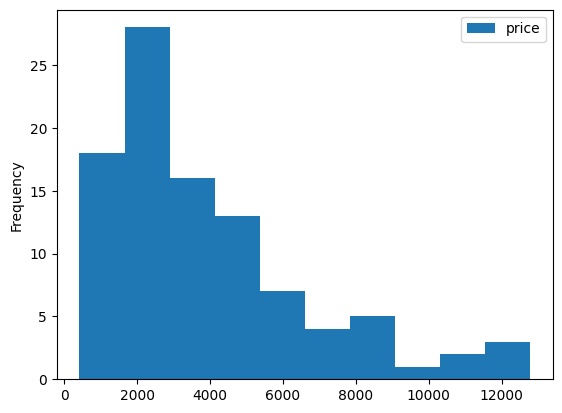

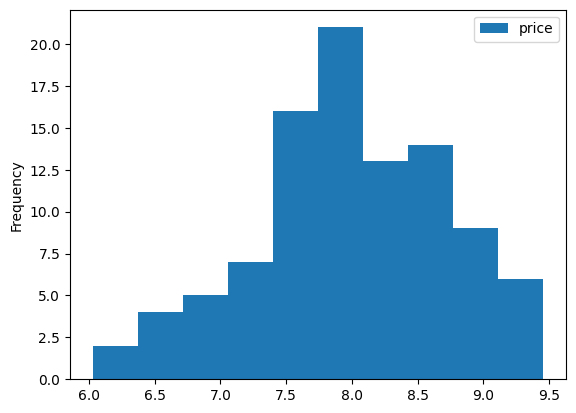

In [49]:
# Method 2: Assign (continuation)
df[['model', 'price']]

df[['model', 'price']] \
    .drop_duplicates()

df[['model', 'price']] \
    .drop_duplicates() \
    .set_index('model')

df[['model', 'price']] \
    .drop_duplicates() \
    .set_index('model') \
    .plot(kind='hist')

# The plot is skewed.  When outliers are present, they skew data.The outliers can have a drastic effect 
# on linear regression models. One way to compensate for skew is to take a Log Transformation.
# We can implement it with df.assign()
df[['model', 'price']] \
    .drop_duplicates() \
    .assign(price = lambda x: np.log(x['price'])) \
    .set_index('model') \
    .plot(kind='hist')

In [50]:
# Adding Flags (True/False)
"Supersix Evo Hi-Mod Team"

# .find("supersix"): This is the string method that searches for the position of the substring "supersix".
# How .find() works: It returns the index (position) where the substring first begins.
# Since "supersix" starts at the very beginning of the new lowercase string, its index is 0.
"Supersix Evo Hi-Mod Team".lower().find("supersix")
"Supersix Evo Hi-Mod Team".lower().find("supersix") >= 0

"Beast of the East 1"
"Beast of the East 1".lower().find("supersix") # it returns -1, it means that it does not exist
"Beast of the East 1".lower().find("supersix") >= 0 # Returns False

# Pandas Series has the str.contains() method, which simplifies text searching, so we don't need to use find() >= 0
df.assign(flag_supersix = lambda x: x['model']) # It creates the col which is a copy of model
df.assign(flag_supersix = lambda x: x['model'].str.lower()) # same as before but lowercase
df.assign(flag_supersix = lambda x: x['model'].str.lower().str.contains("supersix"))

,order_id,order_line,order_date,quantity,price,total_price,model,category_1,category_2,frame_material,bikeshop_name,city,state,flag_supersix
0,1,1,2011-01-07,1,6070,6070,Jekyll Carbon 2,Mountain,Over Mountain,Carbon,Ithaca Mountain Climbers,Ithaca,NY,False
1,1,2,2011-01-07,1,5970,5970,Trigger Carbon 2,Mountain,Over Mountain,Carbon,Ithaca Mountain Climbers,Ithaca,NY,False
2,2,1,2011-01-10,1,2770,2770,Beast of the East 1,Mountain,Trail,Aluminum,Kansas City 29ers,Kansas City,KS,False
3,2,2,2011-01-10,1,5970,5970,Trigger Carbon 2,Mountain,Over Mountain,Carbon,Kansas City 29ers,Kansas City,KS,False
4,3,1,2011-01-10,1,10660,10660,Supersix Evo Hi-Mod Team,Road,Elite Road,Carbon,Louisville Race Equipment,Louisville,KY,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15639,2000,4,2015-12-25,1,2660,2660,CAAD Disc Ultegra,Road,Elite Road,Aluminum,Austin Cruisers,Austin,TX,False
15640,2000,5,2015-12-25,1,1350,1350,Trail 2,Mountain,Sport,Aluminum,Austin Cruisers,Austin,TX,False
15641,2000,6,2015-12-25,1,1680,1680,CAAD12 105,Road,Elite Road,Aluminum,Austin Cruisers,Austin,TX,False
15642,2000,7,2015-12-25,1,2880,2880,F-Si Carbon 4,Mountain,Cross Country Race,Carbon,Austin Cruisers,Austin,TX,False


In [51]:
# Binning
# A great way to convert numeric data to groups based on their values
# There are two main types:
# 1. Even-Width Binning, pd.cut()
# 2. Quantile Binning, pd.qcut()

pd.cut(df.price, bins = 3)
# Categorical data: Combines a text label with a numeric value (order)
pd.cut(df.price, bins = 3, labels = ['low', 'medium', 'high']) # Categories object
pd.cut(df.price, bins = 3, labels = ['low', 'medium', 'high']).astype("str") # String object

df[['model', 'price']]
df[['model', 'price']] \
    .drop_duplicates() 

df[['model', 'price']] \
    .drop_duplicates() \
    .assign(price_group = lambda x: pd.cut(x.price, bins=3))

,model,price,price_group
0,Jekyll Carbon 2,6070,"(4540.0, 8665.0]"
1,Trigger Carbon 2,5970,"(4540.0, 8665.0]"
2,Beast of the East 1,2770,"(402.625, 4540.0]"
4,Supersix Evo Hi-Mod Team,10660,"(8665.0, 12790.0]"
5,Jekyll Carbon 4,3200,"(402.625, 4540.0]"
...,...,...,...
234,Habit 4,2880,"(402.625, 4540.0]"
248,Habit Hi-Mod Black Inc.,12250,"(8665.0, 12790.0]"
253,F-Si Hi-Mod 1,6390,"(4540.0, 8665.0]"
311,CAAD12 105,1680,"(402.625, 4540.0]"


In [52]:
# Visualizing Binning Strategies with a Pandas Heat Table
# Pandas DF Style Accessor. Data frames have a style accessor that many data scientists don't know about.
# It is really powerful for making tables for HTML and Excel reports

# df.pivot(). Used to reshape a data frame from long to wide format
df[['model', 'price']] \
    .drop_duplicates() \
    .assign(price_group = lambda x: pd.cut(x.price, bins=3)) \
    .pivot(
        index = 'model',
        columns = 'price_group',
        values = 'price'
    )

df[['model', 'price']] \
    .drop_duplicates() \
    .assign(price_group = lambda x: pd.cut(x.price, bins=3)) \
    .pivot(
        index = 'model',
        columns = 'price_group',
        values = 'price'
    ) \
    .style.background_gradient(cmap = 'Blues')

price_group,"(402.625, 4540.0]","(4540.0, 8665.0]","(8665.0, 12790.0]"
model,,,
Bad Habit 1,3200.000000,nan,nan
Bad Habit 2,2660.000000,nan,nan
Beast of the East 1,2770.000000,nan,nan
Beast of the East 2,2130.000000,nan,nan
Beast of the East 3,1620.000000,nan,nan
CAAD Disc Ultegra,2660.000000,nan,nan
CAAD12 105,1680.000000,nan,nan
CAAD12 Black Inc,nan,5860.000000,nan
CAAD12 Disc 105,1950.000000,nan,nan


In [53]:
# Quantile Binning with pd.qcut()
# It adjusts the bin widths to evenly distribute observations across all bins.
# This method is used most of the time when binning

pd.qcut(df.price, q=[0, 0.33, 0.66, 1])
pd.qcut(df.price, q=[0, 0.33, 0.66, 1], labels=['low', 'medium', 'high'])

# Provide the quantiles using q
df[['model', 'price']] \
    .drop_duplicates() \
    .assign(price_group = lambda x: pd.qcut(x.price, q=3)) \
    .pivot(
        index = 'model',
        columns = 'price_group',
        values = 'price'
    ) \
    .style.background_gradient(cmap = 'Blues')

price_group,"(414.999, 2240.0]","(2240.0, 4260.0]","(4260.0, 12790.0]"
model,,,
Bad Habit 1,nan,3200.000000,nan
Bad Habit 2,nan,2660.000000,nan
Beast of the East 1,nan,2770.000000,nan
Beast of the East 2,2130.000000,nan,nan
Beast of the East 3,1620.000000,nan,nan
CAAD Disc Ultegra,nan,2660.000000,nan
CAAD12 105,1680.000000,nan,nan
CAAD12 Black Inc,nan,nan,5860.000000
CAAD12 Disc 105,1950.000000,nan,nan


In [57]:
# Close the connection
%sql --close sqlite:///bike_orders_database.sqlite

Exception: Could not close connection because it was not found amongst these: dict_keys([])